In [13]:
!apt-get -y install fonts-noto-cjk > /dev/null 2>&1

import matplotlib
import matplotlib.pyplot as plt
matplotlib.font_manager.fontManager.addfont(
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
)
matplotlib.rc('font', family='Noto Sans CJK JP')
plt.rcParams['axes.unicode_minus'] = False

In [1]:
# Step 1: kaggle.json をColabにアップロード
from google.colab import files
files.upload()

# Step 2: 認証設定
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Step 3: Titanicデータをダウンロード
!kaggle competitions download -c titanic
!unzip -o titanic.zip

# Step 4: 読み込み確認
import pandas as pd
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'train: {train.shape}')
print(f'test : {test.shape}')
train.head()

Saving kaggle.json to kaggle.json
100% 34.1k/34.1k [00:00<00:00, 54.9MB/s]

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
train: (891, 12)
test : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')

print("処理前の欠損数:")
print(df[['Age', 'Cabin', 'Embarked']].isnull().sum())

処理前の欠損数:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [4]:
# 1. Age：Pclass × Sex グループの中央値で補完

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Age 欠損数（補完後）: {df['Age'].isnull().sum()}")

Age 欠損数（補完後）: 0


In [5]:
# 2. Cabin：Has_Cabin フラグ列に変換して元列を削除

df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

print(f"Has_Cabin の値の分布:\n{df['Has_Cabin'].value_counts()}")

Has_Cabin の値の分布:
Has_Cabin
0    687
1    204
Name: count, dtype: int64


In [6]:
# 3. Embarked：最頻値で補完

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(f"Embarked 欠損数（補完後）: {df['Embarked'].isnull().sum()}")

Embarked 欠損数（補完後）: 0


In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


In [9]:
# 施策1: 称号（Title）の抽出

# 正規表現で "," と "." の間の称号を抽出
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

print("称号の種類と件数:")
print(df['Title'].value_counts())

# "Mlle" と "Ms" は "Miss" と同義、"Mme" は "Mrs" と同義
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 希少な称号はまとめて 'Rare' に統合
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

print("\n統合後の称号:")
print(df['Title'].value_counts())

称号の種類と件数:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

統合後の称号:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


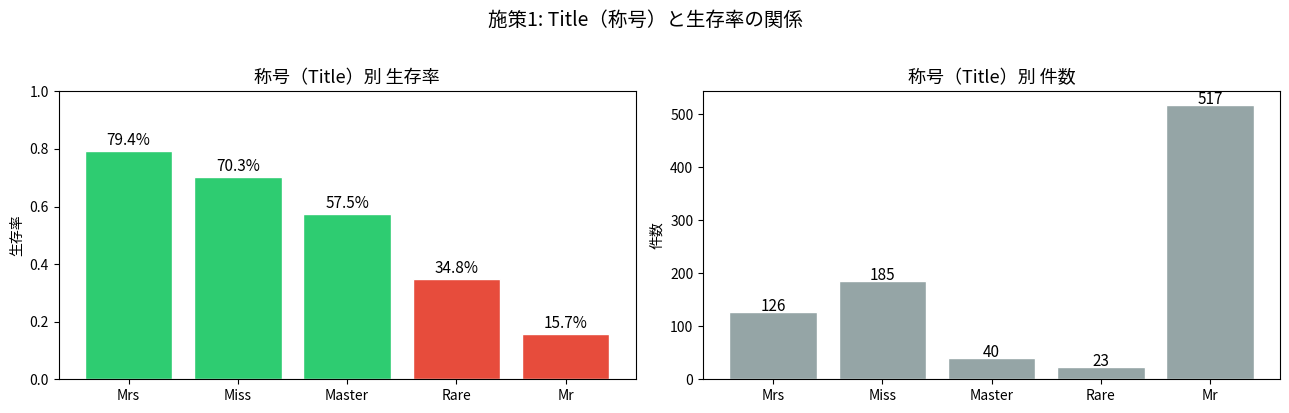

In [14]:
# --- 根拠グラフ ---
title_stats = df.groupby('Title')['Survived'].agg(['mean', 'count']).reset_index()
title_stats.columns = ['Title', 'SurvivalRate', 'Count']
title_stats = title_stats.sort_values('SurvivalRate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：称号別生存率
bars = axes[0].bar(title_stats['Title'], title_stats['SurvivalRate'],
                   color=['#2ecc71' if r > 0.5 else '#e74c3c'
                          for r in title_stats['SurvivalRate']],
                   edgecolor='white')
axes[0].set_title('称号（Title）別 生存率', fontsize=13)
axes[0].set_ylabel('生存率')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, title_stats['SurvivalRate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.1%}', ha='center', fontsize=11)

# 右：称号別件数（信頼性の確認）
axes[1].bar(title_stats['Title'], title_stats['Count'],
            color='#95a5a6', edgecolor='white')
axes[1].set_title('称号（Title）別 件数', fontsize=13)
axes[1].set_ylabel('件数')
for bar, val in zip(axes[1].patches, title_stats['Count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontsize=11)

plt.suptitle('施策1: Title（称号）と生存率の関係', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_title.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 施策2: 家族人数（Family_Size）の作成

# 本人を含めた家族全体の人数
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# さらに「一人 / 小家族(2〜4) / 大家族(5〜)」にカテゴリ化
def family_group(n):
    if n == 1:
        return 'Alone'
    elif n <= 4:
        return 'Small'
    else:
        return 'Large'

df['Family_Group'] = df['Family_Size'].apply(family_group)

print(df['Family_Group'].value_counts())

Family_Group
Alone    537
Small    292
Large     62
Name: count, dtype: int64


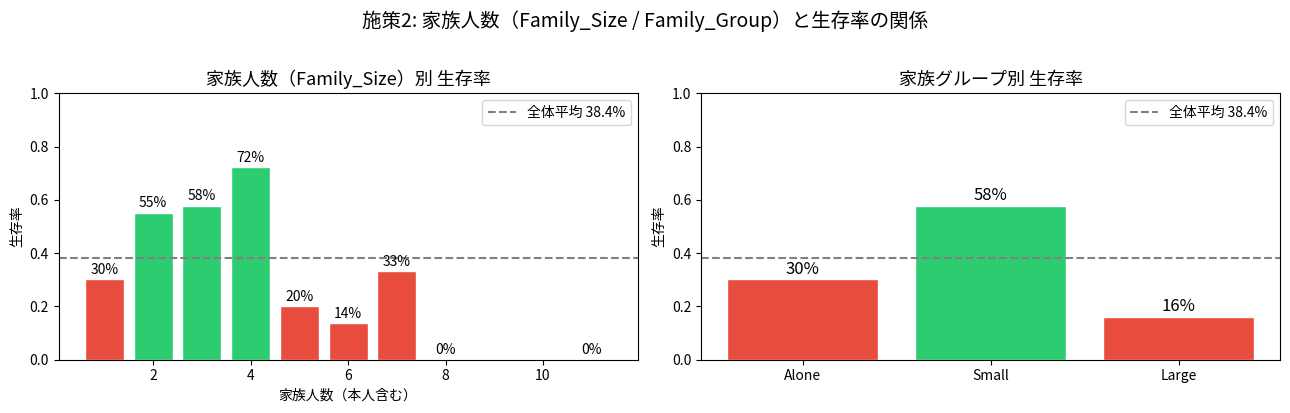

In [15]:
# --- 根拠グラフ ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：家族人数（連続値）別の生存率
size_survival = df.groupby('Family_Size')['Survived'].mean()
colors = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in size_survival.values]
bars = axes[0].bar(size_survival.index, size_survival.values,
                   color=colors, edgecolor='white')
axes[0].set_title('家族人数（Family_Size）別 生存率', fontsize=13)
axes[0].set_xlabel('家族人数（本人含む）')
axes[0].set_ylabel('生存率')
axes[0].set_ylim(0, 1)
axes[0].axhline(df['Survived'].mean(), color='gray',
                linestyle='--', label=f'全体平均 {df["Survived"].mean():.1%}')
axes[0].legend()
for bar, val in zip(bars, size_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.0%}', ha='center', fontsize=10)

# 右：グループ別生存率
group_order = ['Alone', 'Small', 'Large']
group_survival = df.groupby('Family_Group')['Survived'].mean().reindex(group_order)
group_colors = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in group_survival.values]
bars2 = axes[1].bar(group_order, group_survival.values,
                    color=group_colors, edgecolor='white')
axes[1].set_title('家族グループ別 生存率', fontsize=13)
axes[1].set_ylabel('生存率')
axes[1].set_ylim(0, 1)
axes[1].axhline(df['Survived'].mean(), color='gray', linestyle='--',
                label=f'全体平均 {df["Survived"].mean():.1%}')
axes[1].legend()
for bar, val in zip(bars2, group_survival.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.0%}', ha='center', fontsize=12)

plt.suptitle('施策2: 家族人数（Family_Size / Family_Group）と生存率の関係',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_family.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# 施策3: Fare の対数変換 + ビン分割（Fare_Band）

# 対数変換
df['Fare_Log'] = np.log1p(df['Fare'])

# 4つのビンに分割
df['Fare_Band'], bins = pd.qcut(
    df['Fare_Log'], q=4,
    labels=['Low', 'Mid', 'High', 'VeryHigh'],
    retbins=True
)

print("Fare_Band の件数:")
print(df['Fare_Band'].value_counts().sort_index())

Fare_Band の件数:
Fare_Band
Low         223
Mid         224
High        222
VeryHigh    222
Name: count, dtype: int64


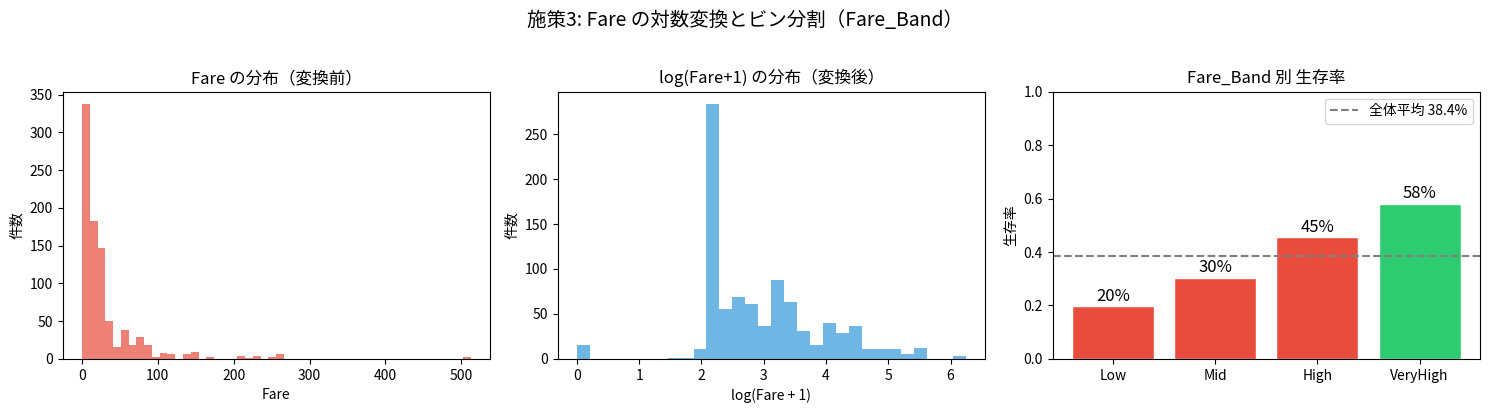

In [17]:
# 根拠グラフ
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 左：元のFare分布
df['Fare'].plot.hist(ax=axes[0], bins=50, color='#e74c3c', alpha=0.7)
axes[0].set_title('Fare の分布（変換前）', fontsize=12)
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('件数')

# 中：対数変換後の分布
df['Fare_Log'].plot.hist(ax=axes[1], bins=30, color='#3498db', alpha=0.7)
axes[1].set_title('log(Fare+1) の分布（変換後）', fontsize=12)
axes[1].set_xlabel('log(Fare + 1)')
axes[1].set_ylabel('件数')

# 右：Fare_Band別の生存率
band_order = ['Low', 'Mid', 'High', 'VeryHigh']
band_survival = df.groupby('Fare_Band', observed=True)['Survived'].mean().reindex(band_order)
band_colors = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in band_survival.values]
bars = axes[2].bar(band_order, band_survival.values,
                   color=band_colors, edgecolor='white')
axes[2].set_title('Fare_Band 別 生存率', fontsize=12)
axes[2].set_ylabel('生存率')
axes[2].set_ylim(0, 1)
axes[2].axhline(df['Survived'].mean(), color='gray', linestyle='--',
                label=f'全体平均 {df["Survived"].mean():.1%}')
axes[2].legend(fontsize=10)
for bar, val in zip(bars, band_survival.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.0%}', ha='center', fontsize=12)

plt.suptitle('施策3: Fare の対数変換とビン分割（Fare_Band）', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('feature_fare.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# 最終確認：追加した特徴量の一覧

new_features = ['Title', 'Family_Size', 'Family_Group', 'Fare_Log', 'Fare_Band']

print("=== 追加した特徴量 ===")
print(df[new_features].head(8))
print(f"\nデータ形状: {df.shape}")

=== 追加した特徴量 ===
    Title  Family_Size Family_Group  Fare_Log Fare_Band
0      Mr            2        Small  2.110213       Low
1     Mrs            2        Small  4.280593  VeryHigh
2    Miss            1        Alone  2.188856       Mid
3     Mrs            2        Small  3.990834  VeryHigh
4      Mr            1        Alone  2.202765       Mid
5      Mr            1        Alone  2.246893       Mid
6      Mr            1        Alone  3.967694  VeryHigh
7  Master            5        Large  3.094446      High

データ形状: (891, 17)


In [19]:
# エンコーディング（カテゴリ → 数値変換）
df_model = df.copy()

# 二値カテゴリ → 0/1
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

# 多値カテゴリ → ダミー変数（One-Hot Encoding）
df_model = pd.get_dummies(df_model, columns=['Embarked', 'Title', 'Family_Group', 'Fare_Band'],
                          drop_first=False)

# モデルに使わない列を削除
drop_cols = ['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Fare']
df_model.drop(columns=drop_cols, inplace=True)

print(f"使用する特徴量数: {df_model.shape[1] - 1}")
print(df_model.columns.tolist())

使用する特徴量数: 21
['Survived', 'Pclass', 'Sex', 'Age', 'Has_Cabin', 'Family_Size', 'Fare_Log', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Family_Group_Alone', 'Family_Group_Large', 'Family_Group_Small', 'Fare_Band_Low', 'Fare_Band_Mid', 'Fare_Band_High', 'Fare_Band_VeryHigh']


In [20]:
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

print(f"X shape: {X.shape}")
print(f"y の分布:\n{y.value_counts()}")

X shape: (891, 21)
y の分布:
Survived
0    549
1    342
Name: count, dtype: int64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
import numpy as np
import matplotlib.pyplot as plt

# Pipeline でスケーリング → モデルをセット
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

# Stratified 5-Fold CV（クラス比率を各foldで維持する）
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    lr_pipe, X, y, cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True
)

print("=== 5-Fold Cross Validation 結果 ===")
print(f"Accuracy  : {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"AUC       : {results['test_roc_auc'].mean():.4f} ± {results['test_roc_auc'].std():.4f}")
print(f"Train AUC : {results['train_roc_auc'].mean():.4f}  （過学習チェック用）")

=== 5-Fold Cross Validation 結果 ===
Accuracy  : 0.8283 ± 0.0107
AUC       : 0.8763 ± 0.0164
Train AUC : 0.8839  （過学習チェック用）


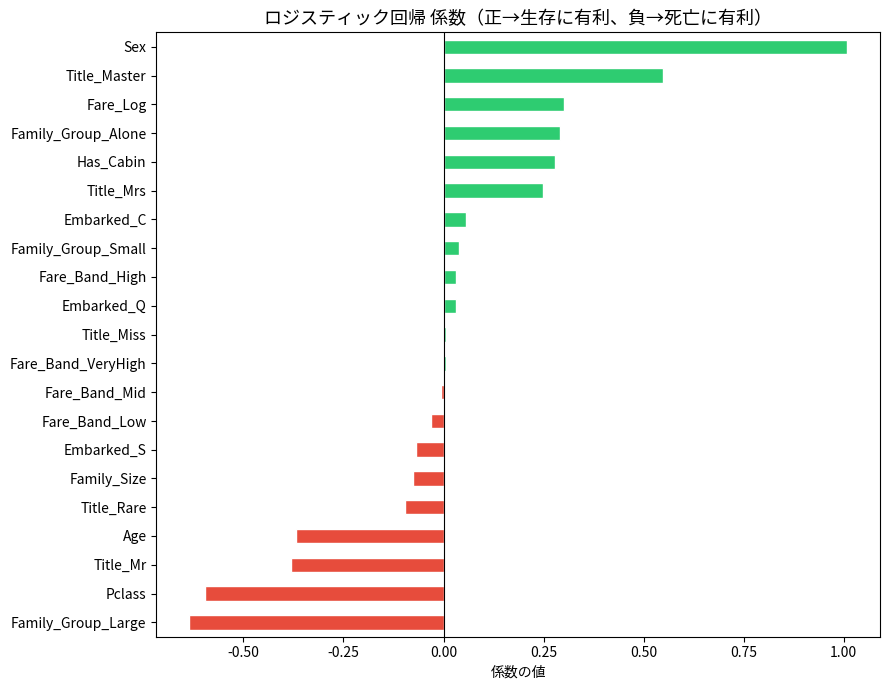

In [22]:
# 全データで学習して係数を確認
lr_pipe.fit(X, y)
lr_model = lr_pipe.named_steps['lr']

coef = pd.Series(lr_model.coef_[0], index=X.columns)
coef_sorted = coef.sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coef_sorted.values]
coef_sorted.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('ロジスティック回帰 係数（正→生存に有利、負→死亡に有利）', fontsize=13)
ax.set_xlabel('係数の値')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

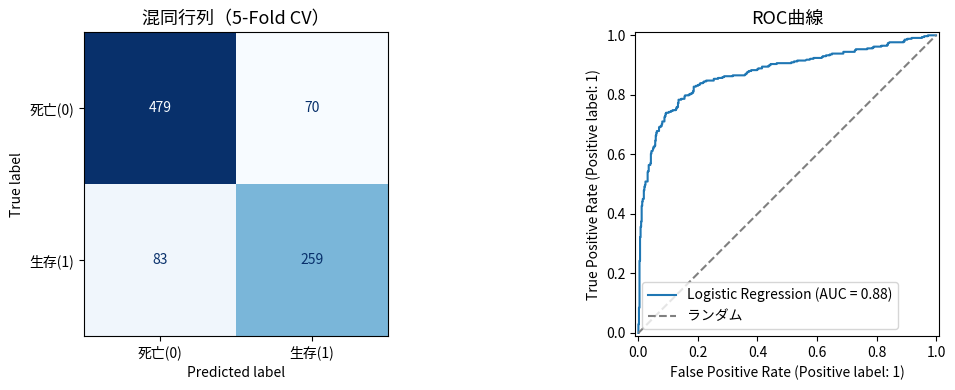


=== 評価指標（CV予測値ベース）===
Accuracy  : 0.8283
AUC       : 0.8752
Precision : 0.7872  （生存と予測した中で本当に生存した割合）
Recall    : 0.7573  （実際の生存者のうち正しく検出できた割合）


In [23]:
from sklearn.model_selection import cross_val_predict

# CV の予測値を取得
y_pred       = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict')
y_pred_proba = cross_val_predict(lr_pipe, X, y, cv=cv, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：混同行列
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['死亡(0)', '生存(1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('混同行列（5-Fold CV）', fontsize=13)

# 右：ROC曲線
RocCurveDisplay.from_predictions(y, y_pred_proba, ax=axes[1], name='Logistic Regression')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray', label='ランダム')
axes[1].set_title('ROC曲線', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# 数値で確認
tn, fp, fn, tp = cm.ravel()
print(f"\n=== 評価指標（CV予測値ベース）===")
print(f"Accuracy  : {accuracy_score(y, y_pred):.4f}")
print(f"AUC       : {roc_auc_score(y, y_pred_proba):.4f}")
print(f"Precision : {tp / (tp + fp):.4f}  （生存と予測した中で本当に生存した割合）")
print(f"Recall    : {tp / (tp + fn):.4f}  （実際の生存者のうち正しく検出できた割合）")

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Step 1: depth を変えて過学習を体験する

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    res = cross_validate(dt, X, y, cv=cv,
                         scoring=['accuracy', 'roc_auc'],
                         return_train_score=True)
    depth_results.append({
        'depth':      str(depth) if depth else 'None',
        'train_auc':  res['train_roc_auc'].mean(),
        'cv_auc':     res['test_roc_auc'].mean(),
        'cv_acc':     res['test_accuracy'].mean(),
    })

df_depth = pd.DataFrame(depth_results)
print(df_depth.to_string(index=False))

depth  train_auc   cv_auc   cv_acc
    1   0.775581 0.767234 0.776662
    2   0.839001 0.823825 0.778909
    3   0.876058 0.853384 0.814795
    4   0.897936 0.849778 0.817036
    5   0.918377 0.845541 0.814795
    6   0.936059 0.839411 0.811437
    8   0.963201 0.816842 0.802442
   10   0.981030 0.801700 0.801343
 None   0.999568 0.792953 0.803578


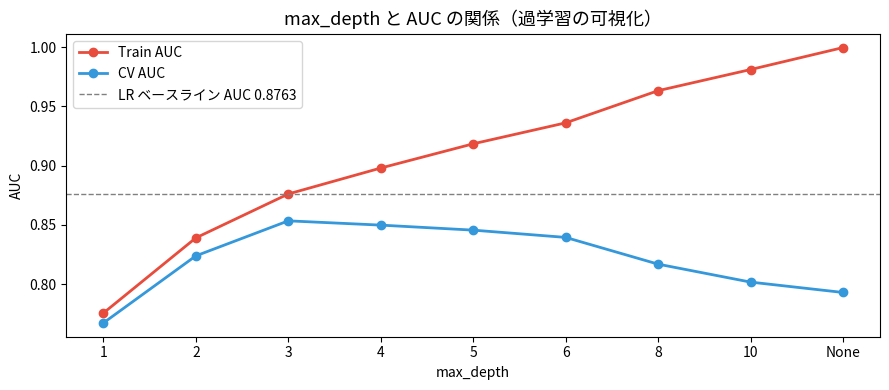


最良の depth: 3  CV AUC: 0.8534


In [25]:
# 過学習の様子をグラフで確認
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_depth['depth'], df_depth['train_auc'],
        marker='o', label='Train AUC', color='#e74c3c', linewidth=2)
ax.plot(df_depth['depth'], df_depth['cv_auc'],
        marker='o', label='CV AUC',    color='#3498db', linewidth=2)
ax.axhline(0.8763, linestyle='--', color='gray', linewidth=1,
           label=f'LR ベースライン AUC 0.8763')
ax.set_title('max_depth と AUC の関係（過学習の可視化）', fontsize=13)
ax.set_xlabel('max_depth')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.savefig('dt_depth_auc.png', dpi=150, bbox_inches='tight')
plt.show()

best_depth = df_depth.loc[df_depth['cv_auc'].idxmax(), 'depth']
best_auc   = df_depth['cv_auc'].max()
print(f"\n最良の depth: {best_depth}  CV AUC: {best_auc:.4f}")

In [26]:
# Step 2: 最良の depth で本番モデルを構築

best_depth_val = int(best_depth) if best_depth != 'None' else None

dt_best = DecisionTreeClassifier(max_depth=best_depth_val, random_state=42)

results_dt = cross_validate(
    dt_best, X, y, cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True
)

print("=== Decision Tree 5-Fold CV 結果 ===")
print(f"Accuracy  : {results_dt['test_accuracy'].mean():.4f} ± {results_dt['test_accuracy'].std():.4f}")
print(f"AUC       : {results_dt['test_roc_auc'].mean():.4f} ± {results_dt['test_roc_auc'].std():.4f}")
print(f"Train AUC : {results_dt['train_roc_auc'].mean():.4f}  （過学習チェック用）")

=== Decision Tree 5-Fold CV 結果 ===
Accuracy  : 0.8148 ± 0.0206
AUC       : 0.8534 ± 0.0217
Train AUC : 0.8761  （過学習チェック用）


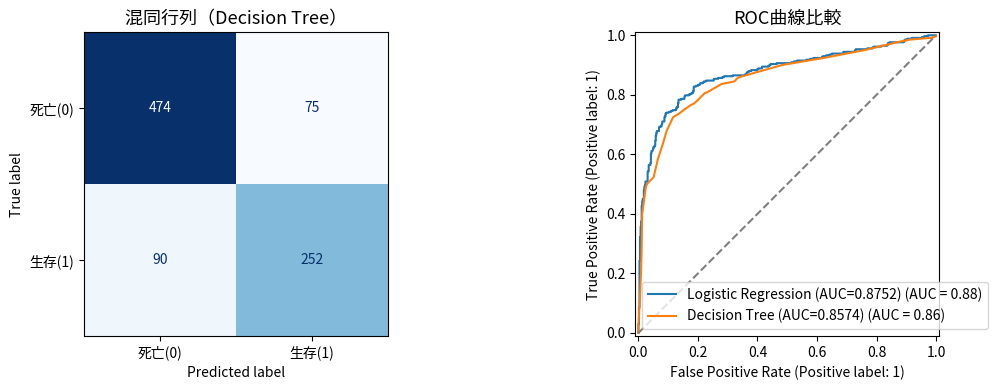


=== 評価指標（Decision Tree）===
Accuracy  : 0.8148
AUC       : 0.8574
Precision : 0.7706
Recall    : 0.7368


In [27]:
# Step 3: 混同行列・ROC曲線・木の可視化

y_pred_dt       = cross_val_predict(dt_best, X, y, cv=cv, method='predict')
y_pred_proba_dt = cross_val_predict(dt_best, X, y, cv=cv, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 混同行列
cm_dt = confusion_matrix(y, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['死亡(0)', '生存(1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('混同行列（Decision Tree）', fontsize=13)

# ROC曲線（LRと重ねて比較）
RocCurveDisplay.from_predictions(
    y, y_pred_proba, ax=axes[1], name=f'Logistic Regression (AUC=0.8752)')
RocCurveDisplay.from_predictions(
    y, y_pred_proba_dt, ax=axes[1], name=f'Decision Tree (AUC={roc_auc_score(y, y_pred_proba_dt):.4f})')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title('ROC曲線比較', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('dt_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"\n=== 評価指標（Decision Tree）===")
print(f"Accuracy  : {accuracy_score(y, y_pred_dt):.4f}")
print(f"AUC       : {roc_auc_score(y, y_pred_proba_dt):.4f}")
print(f"Precision : {tp / (tp + fp):.4f}")
print(f"Recall    : {tp / (tp + fn):.4f}")

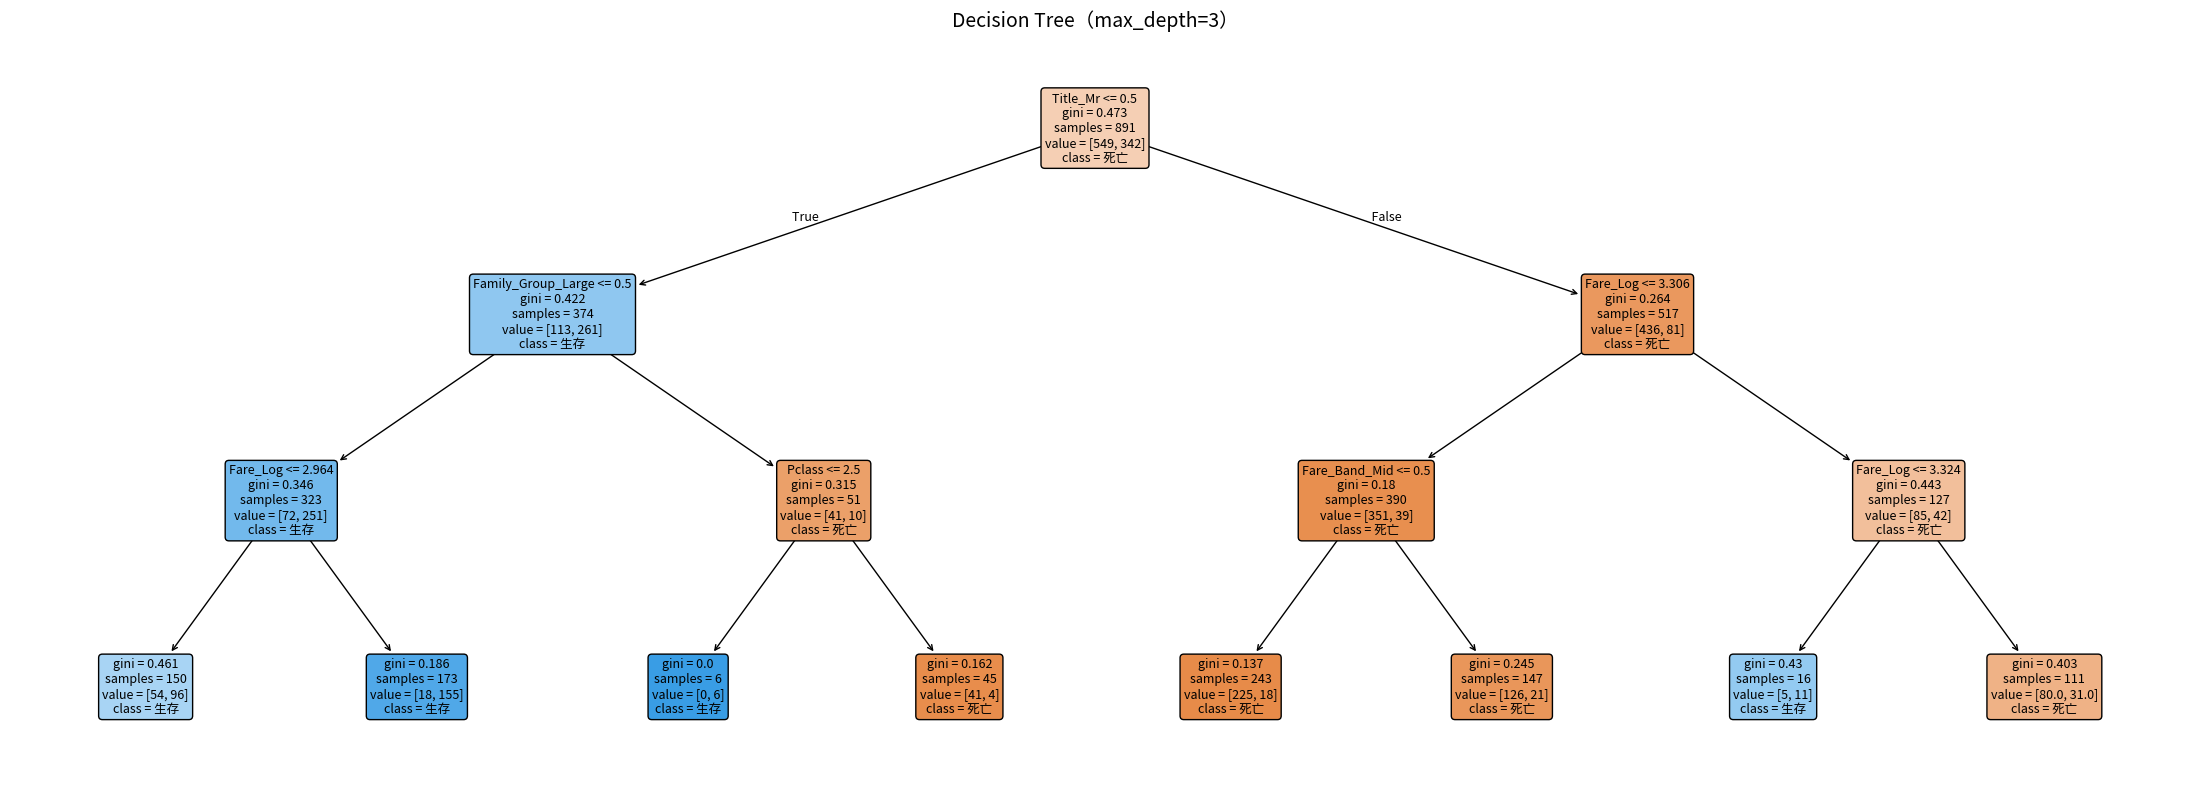

In [28]:
# Step 4: 木の構造を可視化

dt_best.fit(X, y)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_best, feature_names=X.columns,
          class_names=['死亡', '生存'],
          filled=True, rounded=True,
          fontsize=9, ax=ax)
plt.title(f'Decision Tree（max_depth={best_depth_val}）', fontsize=14)
plt.tight_layout()
plt.savefig('dt_tree_structure.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
# Step 5: ここまでの比較表

comparison = pd.DataFrame([
    {
        'モデル':      'Logistic Regression',
        'CV Accuracy': 0.8283,
        'CV AUC':      0.8763,
        'Train AUC':   0.8839,
        'AUCギャップ': 0.0076,
    },
    {
        'モデル':      'Decision Tree',
        'CV Accuracy': results_dt['test_accuracy'].mean(),
        'CV AUC':      results_dt['test_roc_auc'].mean(),
        'Train AUC':   results_dt['train_roc_auc'].mean(),
        'AUCギャップ': (results_dt['train_roc_auc'].mean()
                       - results_dt['test_roc_auc'].mean()),
    },
]).set_index('モデル').round(4)

print("=== モデル比較表（README用）===")
print(comparison.to_string())

=== モデル比較表（README用）===
                     CV Accuracy  CV AUC  Train AUC  AUCギャップ
モデル                                                         
Logistic Regression       0.8283  0.8763     0.8839   0.0076
Decision Tree             0.8148  0.8534     0.8761   0.0227


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: n_estimators（木の本数）の影響を確認

n_estimators_list = [10, 50, 100, 200, 300, 500]
n_est_results = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=42)
    res = cross_validate(rf, X, y, cv=cv,
                         scoring=['accuracy', 'roc_auc'],
                         return_train_score=True)
    n_est_results.append({
        'n_estimators': n,
        'train_auc':    res['train_roc_auc'].mean(),
        'cv_auc':       res['test_roc_auc'].mean(),
        'cv_acc':       res['test_accuracy'].mean(),
    })

df_nest = pd.DataFrame(n_est_results)
print(df_nest.to_string(index=False))

 n_estimators  train_auc   cv_auc   cv_acc
           10   0.995783 0.852781 0.804702
           50   0.997724 0.867231 0.814795
          100   0.997870 0.869138 0.821530
          200   0.997886 0.870914 0.823765
          300   0.997918 0.870991 0.822648
          500   0.997906 0.870797 0.820407


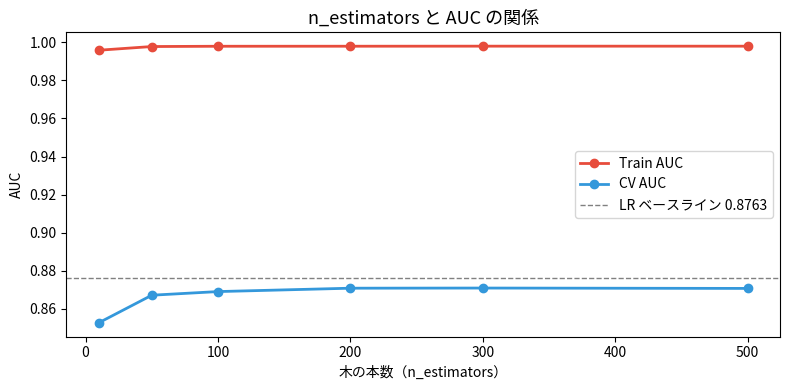

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_nest['n_estimators'], df_nest['train_auc'],
        marker='o', label='Train AUC', color='#e74c3c', linewidth=2)
ax.plot(df_nest['n_estimators'], df_nest['cv_auc'],
        marker='o', label='CV AUC',    color='#3498db', linewidth=2)
ax.axhline(0.8763, linestyle='--', color='gray', linewidth=1,
           label='LR ベースライン 0.8763')
ax.set_title('n_estimators と AUC の関係', fontsize=13)
ax.set_xlabel('木の本数（n_estimators）')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.savefig('rf_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Step 2: 本番モデルの構築・評価

rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,      # 制限なし
    min_samples_leaf=2,  # 葉の最小サンプル数
    n_jobs=-1,
    random_state=42
)

results_rf = cross_validate(
    rf_best, X, y, cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True
)

print("=== Random Forest 5-Fold CV 結果 ===")
print(f"Accuracy  : {results_rf['test_accuracy'].mean():.4f} ± {results_rf['test_accuracy'].std():.4f}")
print(f"AUC       : {results_rf['test_roc_auc'].mean():.4f} ± {results_rf['test_roc_auc'].std():.4f}")
print(f"Train AUC : {results_rf['train_roc_auc'].mean():.4f}  （過学習チェック用）")

=== Random Forest 5-Fold CV 結果 ===
Accuracy  : 0.8384 ± 0.0105
AUC       : 0.8855 ± 0.0188
Train AUC : 0.9722  （過学習チェック用）


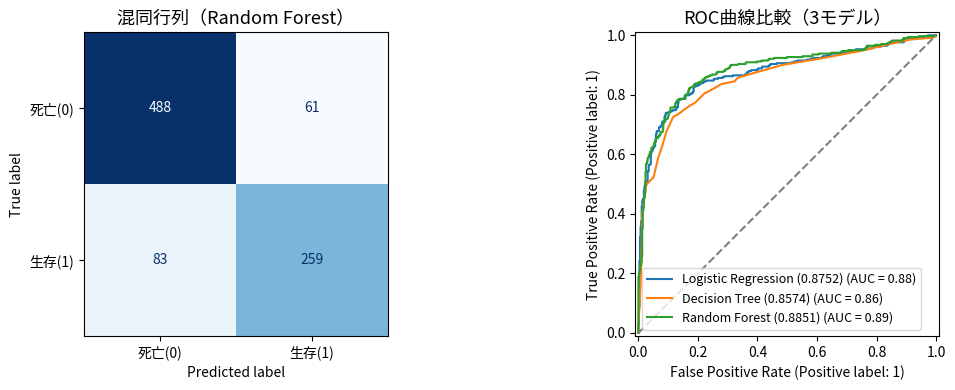


=== 評価指標（Random Forest）===
Accuracy  : 0.8384
AUC       : 0.8851
Precision : 0.8094
Recall    : 0.7573


In [33]:
# Step 3: 混同行列・ROC曲線（3モデル重ねて比較）

y_pred_rf       = cross_val_predict(rf_best, X, y, cv=cv, method='predict')
y_pred_proba_rf = cross_val_predict(rf_best, X, y, cv=cv, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 混同行列
cm_rf = confusion_matrix(y, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['死亡(0)', '生存(1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('混同行列（Random Forest）', fontsize=13)

# ROC曲線（3モデル重ねて比較）
RocCurveDisplay.from_predictions(
    y, y_pred_proba,
    ax=axes[1], name='Logistic Regression (0.8752)')
RocCurveDisplay.from_predictions(
    y, y_pred_proba_dt,
    ax=axes[1], name=f'Decision Tree (0.8574)')
RocCurveDisplay.from_predictions(
    y, y_pred_proba_rf,
    ax=axes[1], name=f'Random Forest ({roc_auc_score(y, y_pred_proba_rf):.4f})')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title('ROC曲線比較（3モデル）', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\n=== 評価指標（Random Forest）===")
print(f"Accuracy  : {accuracy_score(y, y_pred_rf):.4f}")
print(f"AUC       : {roc_auc_score(y, y_pred_proba_rf):.4f}")
print(f"Precision : {tp / (tp + fp):.4f}")
print(f"Recall    : {tp / (tp + fn):.4f}")

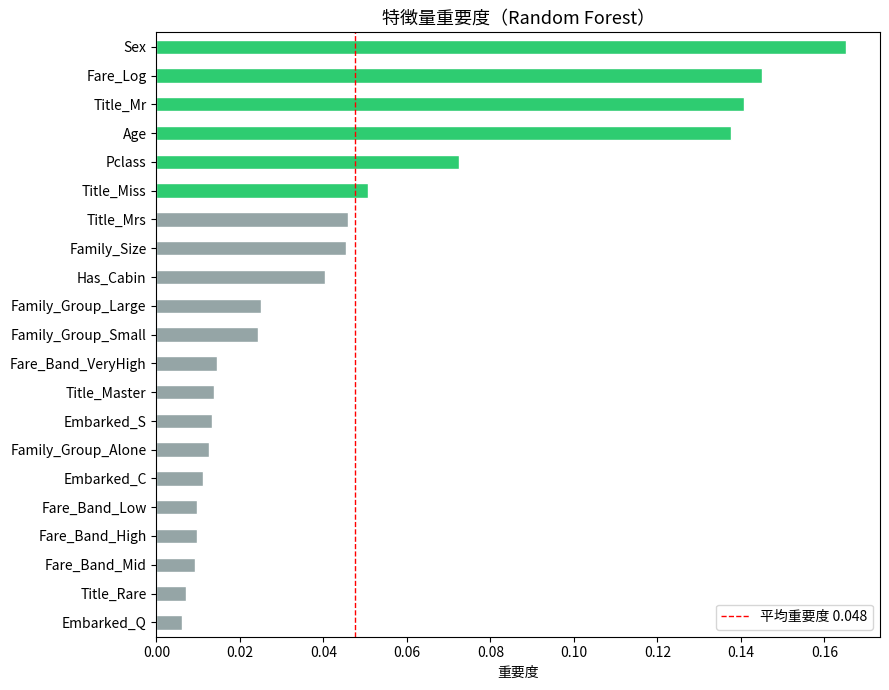


上位5特徴量:
Sex         0.165047
Fare_Log    0.145025
Title_Mr    0.140787
Age         0.137714
Pclass      0.072360
dtype: float64


In [34]:
# Step 4: 特徴量重要度の可視化（RFの強み）

rf_best.fit(X, y)

imp = pd.Series(rf_best.feature_importances_, index=X.columns)
imp_sorted = imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71' if v >= imp.mean() else '#95a5a6' for v in imp_sorted.values]
imp_sorted.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(imp.mean(), color='red', linestyle='--',
           linewidth=1, label=f'平均重要度 {imp.mean():.3f}')
ax.set_title('特徴量重要度（Random Forest）', fontsize=13)
ax.set_xlabel('重要度')
ax.legend()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n上位5特徴量:")
print(imp.sort_values(ascending=False).head())

In [35]:
# Step 5: 比較表を更新

comparison = pd.DataFrame([
    {
        'モデル':       'Logistic Regression',
        'CV Accuracy':  0.8283,
        'CV AUC':       0.8763,
        'Train AUC':    0.8839,
        'AUCギャップ':  0.0076,
    },
    {
        'モデル':       'Decision Tree',
        'CV Accuracy':  0.8148,
        'CV AUC':       0.8534,
        'Train AUC':    0.8761,
        'AUCギャップ':  0.0227,
    },
    {
        'モデル':       'Random Forest',
        'CV Accuracy':  results_rf['test_accuracy'].mean(),
        'CV AUC':       results_rf['test_roc_auc'].mean(),
        'Train AUC':    results_rf['train_roc_auc'].mean(),
        'AUCギャップ':  (results_rf['train_roc_auc'].mean()
                        - results_rf['test_roc_auc'].mean()),
    },
]).set_index('モデル').round(4)

print("=== モデル比較表（README用）===")
print(comparison.to_string())

=== モデル比較表（README用）===
                     CV Accuracy  CV AUC  Train AUC  AUCギャップ
モデル                                                         
Logistic Regression       0.8283  0.8763     0.8839   0.0076
Decision Tree             0.8148  0.8534     0.8761   0.0227
Random Forest             0.8384  0.8855     0.9722   0.0867


In [36]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Step 1: learning_rate と max_depth の影響確認

param_results = []

for lr_val in [0.01, 0.05, 0.1, 0.3]:
    for depth in [3, 4, 5]:
        xgb = XGBClassifier(
            n_estimators=1000,
            learning_rate=lr_val,
            max_depth=depth,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            early_stopping_rounds=50,
            random_state=42,
            verbosity=0
        )
        # early_stopping は CV内で使えないので train/val で代用
        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        xgb.fit(X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False)

        # best_iteration で CV
        xgb_cv = XGBClassifier(
            n_estimators=xgb.best_iteration,
            learning_rate=lr_val,
            max_depth=depth,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        )
        res = cross_validate(xgb_cv, X, y, cv=cv,
                             scoring=['accuracy', 'roc_auc'],
                             return_train_score=True)
        param_results.append({
            'learning_rate': lr_val,
            'max_depth':     depth,
            'best_iter':     xgb.best_iteration,
            'train_auc':     res['train_roc_auc'].mean(),
            'cv_auc':        res['test_roc_auc'].mean(),
            'cv_acc':        res['test_accuracy'].mean(),
        })

df_params = pd.DataFrame(param_results)
print(df_params.sort_values('cv_auc', ascending=False).to_string(index=False))

 learning_rate  max_depth  best_iter  train_auc   cv_auc   cv_acc
          0.01          5        243   0.944365 0.888528 0.838365
          0.01          4        273   0.932709 0.887715 0.839483
          0.05          4         47   0.929073 0.886153 0.837242
          0.10          5         23   0.941631 0.886141 0.838347
          0.10          4         21   0.925781 0.885659 0.834988
          0.30          5          7   0.930161 0.885480 0.842835
          0.05          5         47   0.942929 0.885271 0.837236
          0.30          4          7   0.919625 0.884982 0.834982
          0.01          3        273   0.911053 0.882289 0.835020
          0.10          3         25   0.907806 0.882057 0.831643
          0.05          3         51   0.908215 0.881864 0.832760
          0.30          3         11   0.910664 0.879191 0.835013


In [37]:
# 最良パラメータを取得
best_row = df_params.loc[df_params['cv_auc'].idxmax()]
print(f"\n最良パラメータ:")
print(f"  learning_rate : {best_row['learning_rate']}")
print(f"  max_depth     : {int(best_row['max_depth'])}")
print(f"  best_iter     : {int(best_row['best_iter'])}")
print(f"  CV AUC        : {best_row['cv_auc']:.4f}")


最良パラメータ:
  learning_rate : 0.01
  max_depth     : 5
  best_iter     : 243
  CV AUC        : 0.8885


In [38]:
# Step 2: 最良パラメータで本番モデルを構築

xgb_best = XGBClassifier(
    n_estimators=int(best_row['best_iter']),
    learning_rate=best_row['learning_rate'],
    max_depth=int(best_row['max_depth']),
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

results_xgb = cross_validate(
    xgb_best, X, y, cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True
)

print("=== XGBoost 5-Fold CV 結果 ===")
print(f"Accuracy  : {results_xgb['test_accuracy'].mean():.4f} ± {results_xgb['test_accuracy'].std():.4f}")
print(f"AUC       : {results_xgb['test_roc_auc'].mean():.4f} ± {results_xgb['test_roc_auc'].std():.4f}")
print(f"Train AUC : {results_xgb['train_roc_auc'].mean():.4f}  （過学習チェック用）")

=== XGBoost 5-Fold CV 結果 ===
Accuracy  : 0.8384 ± 0.0213
AUC       : 0.8885 ± 0.0204
Train AUC : 0.9444  （過学習チェック用）


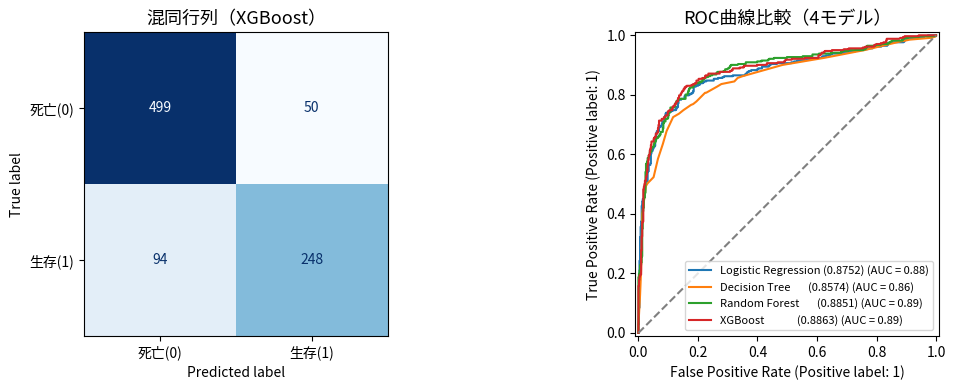


=== 評価指標（XGBoost）===
Accuracy  : 0.8384
AUC       : 0.8863
Precision : 0.8322
Recall    : 0.7251


In [39]:
# Step 3: 混同行列・ROC曲線（4モデル重ねて比較）

y_pred_xgb       = cross_val_predict(xgb_best, X, y, cv=cv, method='predict')
y_pred_proba_xgb = cross_val_predict(xgb_best, X, y, cv=cv, method='predict_proba')[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 混同行列
cm_xgb = confusion_matrix(y, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['死亡(0)', '生存(1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('混同行列（XGBoost）', fontsize=13)

# ROC曲線（4モデル）
for proba, name in [
    (y_pred_proba,     'Logistic Regression (0.8752)'),
    (y_pred_proba_dt,  'Decision Tree       (0.8574)'),
    (y_pred_proba_rf,  f'Random Forest       (0.8851)'),
    (y_pred_proba_xgb, f'XGBoost             ({roc_auc_score(y, y_pred_proba_xgb):.4f})'),
]:
    RocCurveDisplay.from_predictions(y, proba, ax=axes[1], name=name)

axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title('ROC曲線比較（4モデル）', fontsize=13)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('xgb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"\n=== 評価指標（XGBoost）===")
print(f"Accuracy  : {accuracy_score(y, y_pred_xgb):.4f}")
print(f"AUC       : {roc_auc_score(y, y_pred_proba_xgb):.4f}")
print(f"Precision : {tp / (tp + fp):.4f}")
print(f"Recall    : {tp / (tp + fn):.4f}")

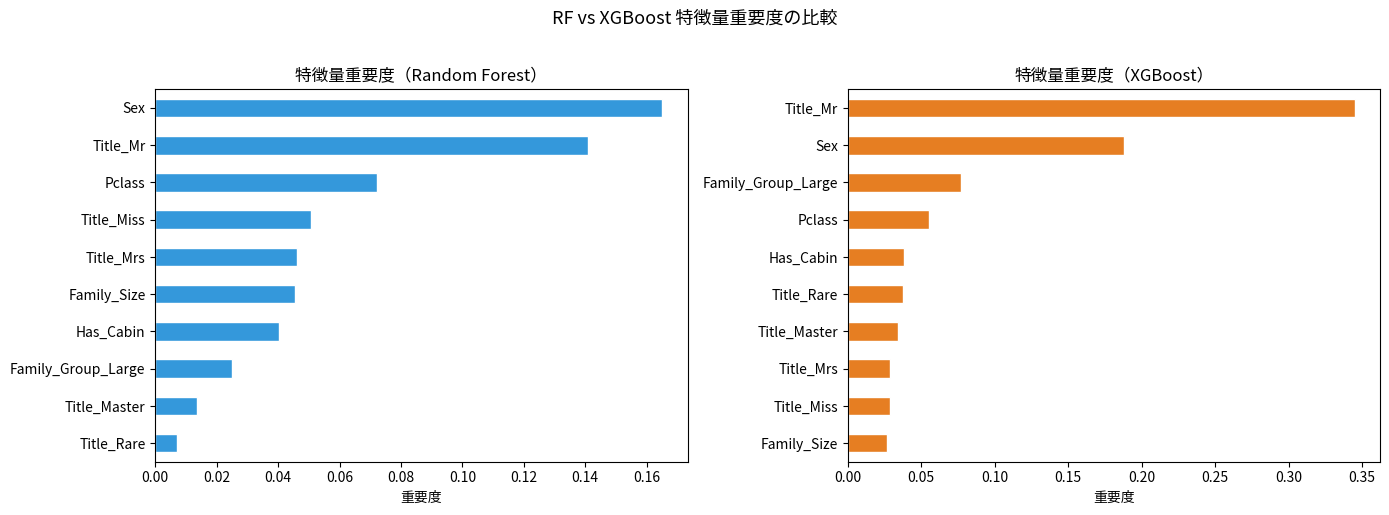

In [40]:
# Step 4: 特徴量重要度（RF と比較）

xgb_best.fit(X, y)

imp_xgb = pd.Series(xgb_best.feature_importances_, index=X.columns)
imp_rf  = pd.Series(rf_best.feature_importances_,  index=X.columns)

# 上位10特徴量を両モデルで並べて比較
top10 = imp_xgb.sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_rf[top10].sort_values().plot.barh(
    ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('特徴量重要度（Random Forest）', fontsize=12)
axes[0].set_xlabel('重要度')

imp_xgb[top10].sort_values().plot.barh(
    ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('特徴量重要度（XGBoost）', fontsize=12)
axes[1].set_xlabel('重要度')

plt.suptitle('RF vs XGBoost 特徴量重要度の比較', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('xgb_vs_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Step 5: 比較表を更新

comparison = pd.DataFrame([
    {
        'モデル':       'Logistic Regression',
        'CV Accuracy':  0.8283,
        'CV AUC':       0.8763,
        'Train AUC':    0.8839,
        'AUCギャップ':  0.0076,
    },
    {
        'モデル':       'Decision Tree',
        'CV Accuracy':  0.8148,
        'CV AUC':       0.8534,
        'Train AUC':    0.8761,
        'AUCギャップ':  0.0227,
    },
    {
        'モデル':       'Random Forest',
        'CV Accuracy':  0.8384,
        'CV AUC':       0.8855,
        'Train AUC':    0.9722,
        'AUCギャップ':  0.0867,
    },
    {
        'モデル':       'XGBoost',
        'CV Accuracy':  results_xgb['test_accuracy'].mean(),
        'CV AUC':       results_xgb['test_roc_auc'].mean(),
        'Train AUC':    results_xgb['train_roc_auc'].mean(),
        'AUCギャップ':  (results_xgb['train_roc_auc'].mean()
                        - results_xgb['test_roc_auc'].mean()),
    },
]).set_index('モデル').round(4)

print("=== モデル比較表（README用）===")
print(comparison.to_string())

=== モデル比較表（README用）===
                     CV Accuracy  CV AUC  Train AUC  AUCギャップ
モデル                                                         
Logistic Regression       0.8283  0.8763     0.8839   0.0076
Decision Tree             0.8148  0.8534     0.8761   0.0227
Random Forest             0.8384  0.8855     0.9722   0.0867
XGBoost                   0.8384  0.8885     0.9444   0.0558
